<a href="https://colab.research.google.com/github/yaseenmlm/Machine-Learning-Projects/blob/main/Kaggle_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Pipeline: Disaster Tweet Classification

This notebook demonstrates a complete pipeline for classifying tweets as 'Disaster' or 'Not Disaster' using a fine-tuned DistilBERT model. The process covers data preparation, model training, evaluation, and visualization of results.

## Pipeline:

1.  **Import Libraries (Cell 1):** Essential libraries for data handling (pandas, numpy), visualization (matplotlib, seaborn), machine learning utilities (scikit-learn), Hugging Face Transformers for DistilBERT, and PyTorch were imported.

2.  **Mount Google Drive & Load Data (Cell 2):** Google Drive was mounted to access external dataset files (`train.csv` and `test.csv` in this case), which were then loaded into pandas DataFrames.

3.  **Split Data (Cell 3):** The dataset was split into training, validation, and test sets. A 15% test set was held out, and the remaining data was further split into 70% for training and 15% for validation, ensuring a robust evaluation strategy.

4.  **Clean Data (Cell 4):** A `clean_text` function was applied to remove URLs, mentions, and extra whitespace from the tweet texts across all splits, preparing the data for tokenization.

5.  **Tokenize Tweets (Cell 5):** The `DistilBertTokenizer` was used to convert the cleaned text into numerical tokens that the DistilBERT model can understand. This included adding special tokens (CLS, SEP), padding, and truncation. The tokenized data was then wrapped in `TweetDataset` objects for efficient batch processing by PyTorch.

6.  **Load DistilBERT Model (Cell 6):** The `DistilBertForSequenceClassification` model was loaded from pre-trained weights (`distilbert-base-uncased`) and configured for 2 output labels (Disaster/Not Disaster). The model was moved to the GPU for faster training.

7.  **Set up Trainer (Cell 7):**
    *   A `compute_metrics` function was defined to calculate accuracy and F1-score during evaluation.
    *   `TrainingArguments` were configured, including setting the output directory, number of epochs (3), batch sizes, a learning rate of 5e-5, warmup steps, weight decay, and evaluation/save strategies.
    *   The `Trainer` object was instantiated with the model, training arguments, datasets, and the `compute_metrics` function.

8.  **Training with Visualization (Cell 7a):**
    *   A `LivePlotCallback` was implemented to visualize training and validation loss, accuracy, and F1-score in real-time after each epoch.
    *   An `EarlyStoppingCallback` with a patience of 3 was added to halt training if the validation loss did not improve for 3 consecutive epochs, preventing overfitting.
    *   The `trainer.train()` method was called to start the fine-tuning process.

9.  **Validation Step (Cell 7b):** After training, a formal evaluation was run on the validation set using `trainer.evaluate()` to get stable metrics without further model updates.

10. **Validation Analysis (Cell 7c):** The model's final performance was assessed on the validation set to understand its unbiased capabilities. Predictions were also generated for detailed analysis, providing a proxy for real-world performance.

11. **Final Comparison and Metrics (Cell 8):**
    *   A comprehensive visualization was generated, including a confusion matrix, training vs. validation loss curve, accuracy and F1-score per epoch, and a bar chart comparing final metrics across train, validation, and test sets.
    *   A detailed classification report and a summary of key performance indicators were printed.

12. **Save Project to Drive (Cell 9):** The entire Colab notebook was saved to Google Drive, ensuring backup and persistence of the work.

In [ ]:
# Cell 1 - Import Lib

# Data handling
import pandas as pd                          # pandas for interacting with csv files
import numpy as np

# Visualization
import matplotlib.pyplot as plt              # graphics and visuals
import seaborn as sns

# Scikit-learn utilities
from sklearn.model_selection import train_test_split   # to split database
from sklearn.metrics import (                          # to measure model performance
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

# Hugging Face Import - for DistilBERT
from transformers import (
    DistilBertTokenizer,        # converts text into numbers DistilBERT understands
    DistilBertForSequenceClassification,  # the actual model
    Trainer,                    # handles the training loop for us
    TrainingArguments           # lets us configure how training runs
)

# PyTorch - the deep learning framework DistilBERT runs on
import torch
from torch.utils.data import Dataset        # for feeding data into the model efficiently

print("All libraries imported successfully!")
print(f"Using device: {'GPU' if torch.cuda.is_available() else 'CPU'}")


All libraries imported successfully!
Using device: GPU


In [ ]:
# Cell 2 - Mount Google Drive and Load Data
from google.colab import drive

# Mount Google Drive so we can access our data files
drive.mount('/content/drive')

# Load the training data (has 'text' and 'target' columns — we learn from this)
train_df = pd.read_csv('/content/drive/MyDrive/Kaggle_Tweets_Database/train.csv')

# Load the Kaggle test data (has 'text' but NO 'target' column — this is what we submit predictions for)
test_df = pd.read_csv('/content/drive/MyDrive/Kaggle_Tweets_Database/test.csv')

print(f"Training data loaded: {train_df.shape[0]} rows")
print(f"Test data loaded:     {test_df.shape[0]} rows")
print("\nTraining sample:")
print(train_df.head())
print("\nTest sample:")
print(test_df.head())

Mounted at /content/drive
Training data loaded: 7613 rows
Test data loaded:     3263 rows

Training sample:
   id keyword location                                               text  \
0   1     NaN      NaN  Our Deeds are the Reason of this #earthquake M...   
1   4     NaN      NaN             Forest fire near La Ronge Sask. Canada   
2   5     NaN      NaN  All residents asked to 'shelter in place' are ...   
3   6     NaN      NaN  13,000 people receive #wildfires evacuation or...   
4   7     NaN      NaN  Just got sent this photo from Ruby #Alaska as ...   

   target  
0       1  
1       1  
2       1  
3       1  
4       1  

Test sample:
   id keyword location                                               text
0   0     NaN      NaN                 Just happened a terrible car crash
1   2     NaN      NaN  Heard about #earthquake is different cities, s...
2   3     NaN      NaN  there is a forest fire at spot pond, geese are...
3   9     NaN      NaN           Apocalypse lig

In [ ]:
# Cell 3 - Split Training Data into Train and Validation Sets
# NOTE: We do NOT create a test set here because test.csv from Kaggle IS our test set.
# The Kaggle test.csv has no labels — we predict on it and submit those predictions.
from sklearn.model_selection import train_test_split

# Use only the training data for our train/val split
X = train_df['text']    # tweet text (input features)
y = train_df['target']  # disaster label: 1 = disaster, 0 = not disaster

# Split: 85% for training, 15% for validation
# Validation set lets us monitor performance during training without touching the Kaggle test set
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.15, random_state=42
    )

    # Keep the Kaggle test tweet text and IDs separate for submission later
X_kaggle_test = test_df['text']         # tweet text we need to predict
kaggle_test_ids = test_df['id']         # IDs we need in the submission file

print(f"Training samples:   {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Kaggle test tweets: {len(X_kaggle_test)} (no labels — for submission)")

Training samples:   6471
Validation samples: 1142
Kaggle test tweets: 3263 (no labels — for submission)


In [ ]:
# Cell 4 - Clean Data
# Removes URLs, @mentions, and extra whitespace from tweet text
# This helps the model focus on the actual words rather than noise
import re

def clean_text(text):
    text = re.sub(r'http\S+', '', text)       # remove URLs (e.g. https://t.co/...)
    text = re.sub(r'@\w+', '', text)           # remove @mentions (e.g. @user)
    text = re.sub(r'\s+', ' ', text).strip()  # collapse multiple spaces into one
    return text

# Apply cleaning to training and validation splits
X_train = X_train.apply(clean_text)
X_val   = X_val.apply(clean_text)

# Also clean the Kaggle test tweets — same preprocessing must be applied
X_kaggle_test = X_kaggle_test.apply(clean_text)

# Quick sanity check: show before vs after cleaning for a few training tweets
sample = X_train.iloc[:3]
og_sample = train_df["text"].loc[sample.index]

comparison = pd.DataFrame({
    'original': og_sample.values,
    'cleaned':  sample.values
})
print(comparison.to_string())

                                                                                                                                       original                                                                                                     cleaned
0   ÛÏ@SplottDave: @TeamPalestina That's about 28700 Palestinian homes demolished now by Israel since 1967 w/ 0 Israeli home demolished @POTUS  ÛÏ: That's about 28700 Palestinian homes demolished now by Israel since 1967 w/ 0 Israeli home demolished
1  Rightways: Building structural integrity &amp; failure: inspections damages defects testing  repair http://t.co/vz1irH0Nmm via @rightwaystan      Rightways: Building structural integrity &amp; failure: inspections damages defects testing repair via
2                                                            London Life: photos of a beautiful bombed-out Britain http://t.co/2RAcaiVFfq #arts                                                 London Life: photos of a beautiful bombed-out Britai

In [ ]:
# Cell 5 - Tokenize Tweets
# DistilBERT doesn't read raw text — it needs numbers.
# The tokenizer converts each tweet into token IDs the model understands.
from transformers import DistilBertTokenizer
import torch
from torch.utils.data import Dataset

# Load DistilBERT's tokenizer — must match the model loaded in Cell 6
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

def tokenize(texts, max_length=128):
    """Convert a list of tweet strings into tokenized tensors for DistilBERT."""
    return tokenizer(
        list(texts),
        max_length=max_length,   # cap at 128 tokens (tweets are short, this is plenty)
        padding=True,            # pad shorter tweets with zeros so all batches are the same length
        truncation=True,         # cut off anything longer than 128 tokens
        return_tensors='pt'      # return PyTorch tensors (required by DistilBERT)
    )
    # The tokenizer also automatically adds:
    # [CLS] token at start — its output is used to make the final classification decision
    # [SEP] token at end   — signals where the tweet ends
    # Attention mask        — 1s for real words, 0s for padding (model ignores padding)

print("Tokenizing training set...")
train_encodings = tokenize(X_train)

print("Tokenizing validation set...")
val_encodings = tokenize(X_val)

print("Tokenizing Kaggle test set (no labels — for submission)...")
kaggle_test_encodings = tokenize(X_kaggle_test)

# --- Wrap tokenized data in PyTorch Dataset objects ---
# The Trainer needs a Dataset that serves data in batches (e.g. 16 at a time)
# rather than loading everything at once, which would crash the GPU.

class TweetDataset(Dataset):
    """Dataset for labeled tweets (train / validation) — includes target labels."""
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Return one tweet's token tensors + its true disaster label
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels.iloc[idx])
        return item

class UnlabeledTweetDataset(Dataset):
    """Dataset for Kaggle test tweets — no labels, used only for prediction."""
    def __init__(self, encodings):
        self.encodings = encodings

    def __len__(self):
        return self.encodings['input_ids'].shape[0]

    def __getitem__(self, idx):
        # Return token tensors only — no label because Kaggle test.csv has none
        return {key: val[idx] for key, val in self.encodings.items()}

# Create dataset objects for all three splits
train_dataset       = TweetDataset(train_encodings, y_train)
val_dataset         = TweetDataset(val_encodings, y_val)
kaggle_test_dataset = UnlabeledTweetDataset(kaggle_test_encodings)

print(f"\nTrain dataset size:        {len(train_dataset)}")
print(f"Validation dataset size:   {len(val_dataset)}")
print(f"Kaggle test dataset size:  {len(kaggle_test_dataset)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing training set...
Tokenizing validation set...
Tokenizing Kaggle test set (no labels — for submission)...

Train dataset size:        6471
Validation dataset size:   1142
Kaggle test dataset size:  3263


In [ ]:
# Cell 6 - Load DistilBERT

from transformers import DistilBertForSequenceClassification
import torch

# Reload the model from scratch to ensure a clean state before retraining.
# This discards any previous training and starts with the pre-trained DistilBERT weights.
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2                # 2 because we have 2 classes: disaster and not disaster
)

# move the model to GPU so training is fast
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

print(f"Model reloaded successfully on: {device}")
print(f"Number of parameters: {sum(p.numel() for p in model.parameters()):,}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model reloaded successfully on: cuda
Number of parameters: 66,955,010


In [ ]:
# Cell 7 - Setting up Trainer

from transformers import TrainingArguments, Trainer, EarlyStoppingCallback
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

# compute_metrics is a function that the Trainer uses to evaluate the model's performance
# on the validation set at regular intervals (e.g., after each epoch).
# It takes the model's raw predictions (logits) and true labels, and returns a dictionary of metrics.
def compute_metrics(eval_pred):  # eval_pred is a package that HuggingFace passes into the function after each run (epoch)
    logits, labels = eval_pred  # logits and labels unpacks from eval_pred. Logits is raw scores that the model outputs after each tweet. labels is the correct answers for every tweet in validation set
    predictions = np.argmax(logits, axis=1)    # pick the class with highest score. works by choosing the index of whatever number in the list has higher score. [2.3,-0.4] = 0
    return {
        'accuracy': accuracy_score(labels, predictions),
        'f1': f1_score(labels, predictions, average='weighted')
    }

# TrainingArguments defines all the hyperparameters and settings for the training process.
# This includes how long to train, batch sizes, learning rate schedules, and how often to evaluate and save the model.
training_args = TrainingArguments(
    output_dir='./results_optimized',            # where to save the model checkpoints for this optimized run
    num_train_epochs=3,               # Set to a higher number; early stopping will determine the actual stopping point
    per_device_train_batch_size=16,    # feed 16 tweets at a time to the GPU
    per_device_eval_batch_size=32,     # larger batch is fine for evaluation (no gradients)
    learning_rate=5e-5,                # Add or modify this line to set your desired learning rate
    warmup_steps=100,                  # gradually increase learning rate at the start
    weight_decay=0.01,                 # prevents overfitting by penalizing large weights
    eval_strategy='epoch',             # check validation performance after every epoch
    save_strategy='epoch',             # save a checkpoint after every epoch
    load_best_model_at_end=True,       # automatically keep the best version of the model
    logging_steps=50,                  # print a progress update every 50 steps
    fp16=True,                         # use 16-bit precision to speed up GPU training
    metric_for_best_model='eval_loss', # Monitor validation loss for early stopping
    greater_is_better=False            # For loss, a smaller value is better
)

# The Trainer class orchestrates the entire training and evaluation loop.
# It takes the model, training arguments, datasets, and a function to compute metrics.
# This setup prepares the Trainer to begin the fine-tuning process.
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

print("Trainer configured and ready!")

Trainer configured and ready!


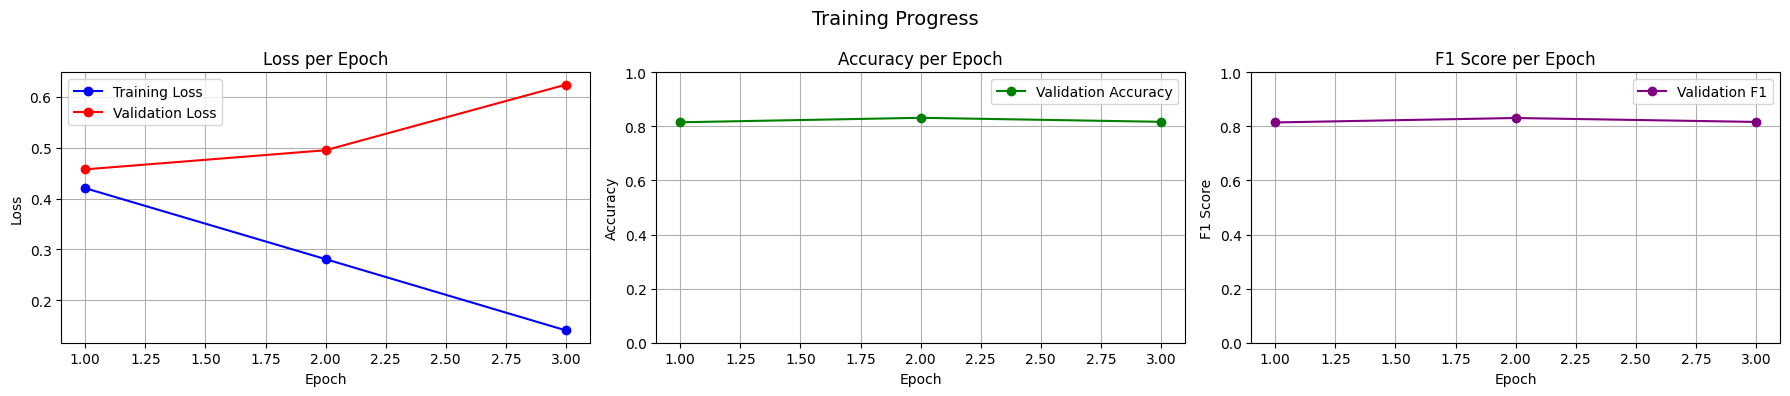


Epoch 3 | Train Loss: 0.1411 | Val Loss: 0.6235 | Accuracy: 0.8170 | F1: 0.8166


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.420194,0.457225,0.815236,0.814624
2,0.280932,0.494757,0.831874,0.831118
3,0.141058,0.623523,0.816988,0.816555



Training complete!


In [ ]:
from transformers import TrainerCallback, EarlyStoppingCallback
import matplotlib.pyplot as plt
from IPython.display import clear_output

# ── Metrics history (kept fresh for each run) ─────────────────────────────────
# This dictionary stores per-epoch metrics so the live plot can draw them.
history = {
    'epoch': [],
    'training_loss': [],
    'validation_loss': [],
    'accuracy': [],
    'f1': []
}

# ── LivePlotCallback ──────────────────────────────────────────────────────────
# A TrainerCallback runs at specific points during training. on_evaluate fires
# after every evaluation, which we set to happen once per epoch in Cell 7.
# This callback redraws three live plots so you can watch progress in real time.
class LivePlotCallback(TrainerCallback):
    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        # Collect metrics for this epoch
        history['epoch'].append(state.epoch)
        history['validation_loss'].append(metrics.get('eval_loss'))
        history['accuracy'].append(metrics.get('eval_accuracy'))
        history['f1'].append(metrics.get('eval_f1'))

        # Grab the latest training loss from the Trainer's internal log
        train_losses = [x['loss'] for x in state.log_history if 'loss' in x]
        if train_losses:
            history['training_loss'].append(train_losses[-1])

        # Redraw all three plots after every epoch
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 3, figsize=(18, 4))
        fig.suptitle('Training Progress', fontsize=14)

        # Plot 1: Loss — both lines should trend downward.
        # If validation loss rises while training loss falls → overfitting.
        axes[0].plot(history['epoch'], history['training_loss'], 'b-o', label='Training Loss')
        axes[0].plot(history['epoch'], history['validation_loss'], 'r-o', label='Validation Loss')
        axes[0].set_title('Loss per Epoch')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].legend()
        axes[0].grid(True)

        # Plot 2: Accuracy — should trend upward each epoch
        axes[1].plot(history['epoch'], history['accuracy'], 'g-o', label='Validation Accuracy')
        axes[1].set_title('Accuracy per Epoch')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Accuracy')
        axes[1].set_ylim([0, 1])
        axes[1].legend()
        axes[1].grid(True)

        # Plot 3: F1 — like accuracy but accounts for class imbalance
        axes[2].plot(history['epoch'], history['f1'], 'purple', marker='o', label='Validation F1')
        axes[2].set_title('F1 Score per Epoch')
        axes[2].set_xlabel('Epoch')
        axes[2].set_ylabel('F1 Score')
        axes[2].set_ylim([0, 1])
        axes[2].legend()
        axes[2].grid(True)

        plt.tight_layout()
        plt.show()
        print(f"\nEpoch {state.epoch:.0f} | Train Loss: {history['training_loss'][-1]:.4f} | "
              f"Val Loss: {history['validation_loss'][-1]:.4f} | "
              f"Accuracy: {history['accuracy'][-1]:.4f} | F1: {history['f1'][-1]:.4f}")




# LivePlotCallback: redraws the loss/accuracy/F1 plots after each evaluation.
trainer.add_callback(LivePlotCallback())

# EarlyStoppingCallback: stops training if validation loss does not improve
# for 'patience' consecutive epochs, preventing unnecessary compute.
# patience=3 means we tolerate 3 bad epochs before giving up.
trainer.add_callback(EarlyStoppingCallback(early_stopping_patience=3))

# ── Start training ────────────────────────────────────────────────────────────
print("\nStarting training...")
trainer.train()
print("\nTraining complete!")

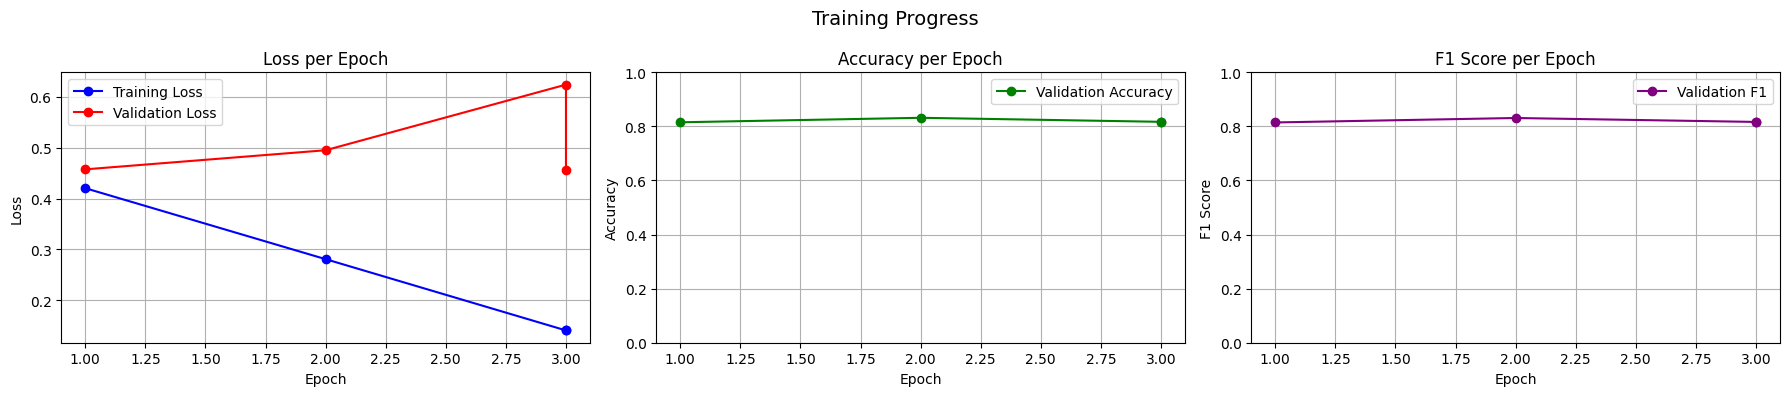


Epoch 3 | Train Loss: 0.1411 | Val Loss: 0.4567 | Accuracy: 0.8152 | F1: 0.8146

Validation Results:
  Loss:     0.4567
  Accuracy: 0.8152
  F1 Score: 0.8146


In [ ]:
# Cell 7b - Validation step

# After training is complete we run a formal evaluation on the validation set
# This is different from the live metrics we saw during training
# During training the model was still updating its weights each batch
# Here the model is frozen (no learning happening) and we get a clean stable measurement
# Think of it as a proper practice exam vs the quick checks we did while studying

print("Running validation evaluation...")

# trainer.evaluate() runs the model on the given dataset in inference mode
# inference mode means the model is just making predictions, not learning
# it automatically uses the compute_metrics function we defined earlier
# to calculate accuracy and f1 alongside the loss

val_results = trainer.evaluate(eval_dataset=val_dataset)

# val_results is the dictionary containing all our metrics
# the keys have the eval prefix added automatically from the trainer

print("\nValidation Results:")
print(f"  Loss:     {val_results['eval_loss']:.4f}")
print(f"  Accuracy: {val_results['eval_accuracy']:.4f}")
print(f"  F1 Score: {val_results['eval_f1']:.4f}")


In [ ]:
# Cell 7c -- Validation Analysis (Final Model Assessment)
# Since the Kaggle test.csv has no labels, we cannot evaluate on it.
# Instead, we do a final analysis on the validation set to understand model performance.
# This is the closest proxy we have to real-world performance before submission.

print("Running final validation analysis...")


val_analysis_results = val_results # Use results from Cell 7b

print("\nValidation Results:")
print(f"  Loss:     {val_analysis_results['eval_loss']:.4f}")
print(f"  Accuracy: {val_analysis_results['eval_accuracy']:.4f}")
print(f"  F1 Score: {val_analysis_results['eval_f1']:.4f}")

# Get predictions on the validation set so we can do deeper analysis in Cell 8
# (predicted class labels + true labels for confusion matrix etc.)
val_predictions = trainer.predict(val_dataset)
predicted_labels = np.argmax(val_predictions.predictions, axis=1)  # pick highest-score class
true_labels = val_predictions.label_ids                             # actual ground truth labels

print(f"\nTotal val tweets analysed: {len(true_labels)}")
print(f"Correctly classified:       {sum(predicted_labels == true_labels)}")
print(f"Incorrectly classified:     {sum(predicted_labels != true_labels)}")

Running final validation analysis...

Validation Results:
  Loss:     0.4567
  Accuracy: 0.8152
  F1 Score: 0.8146



Total val tweets analysed: 1142
Correctly classified:       931
Incorrectly classified:     211


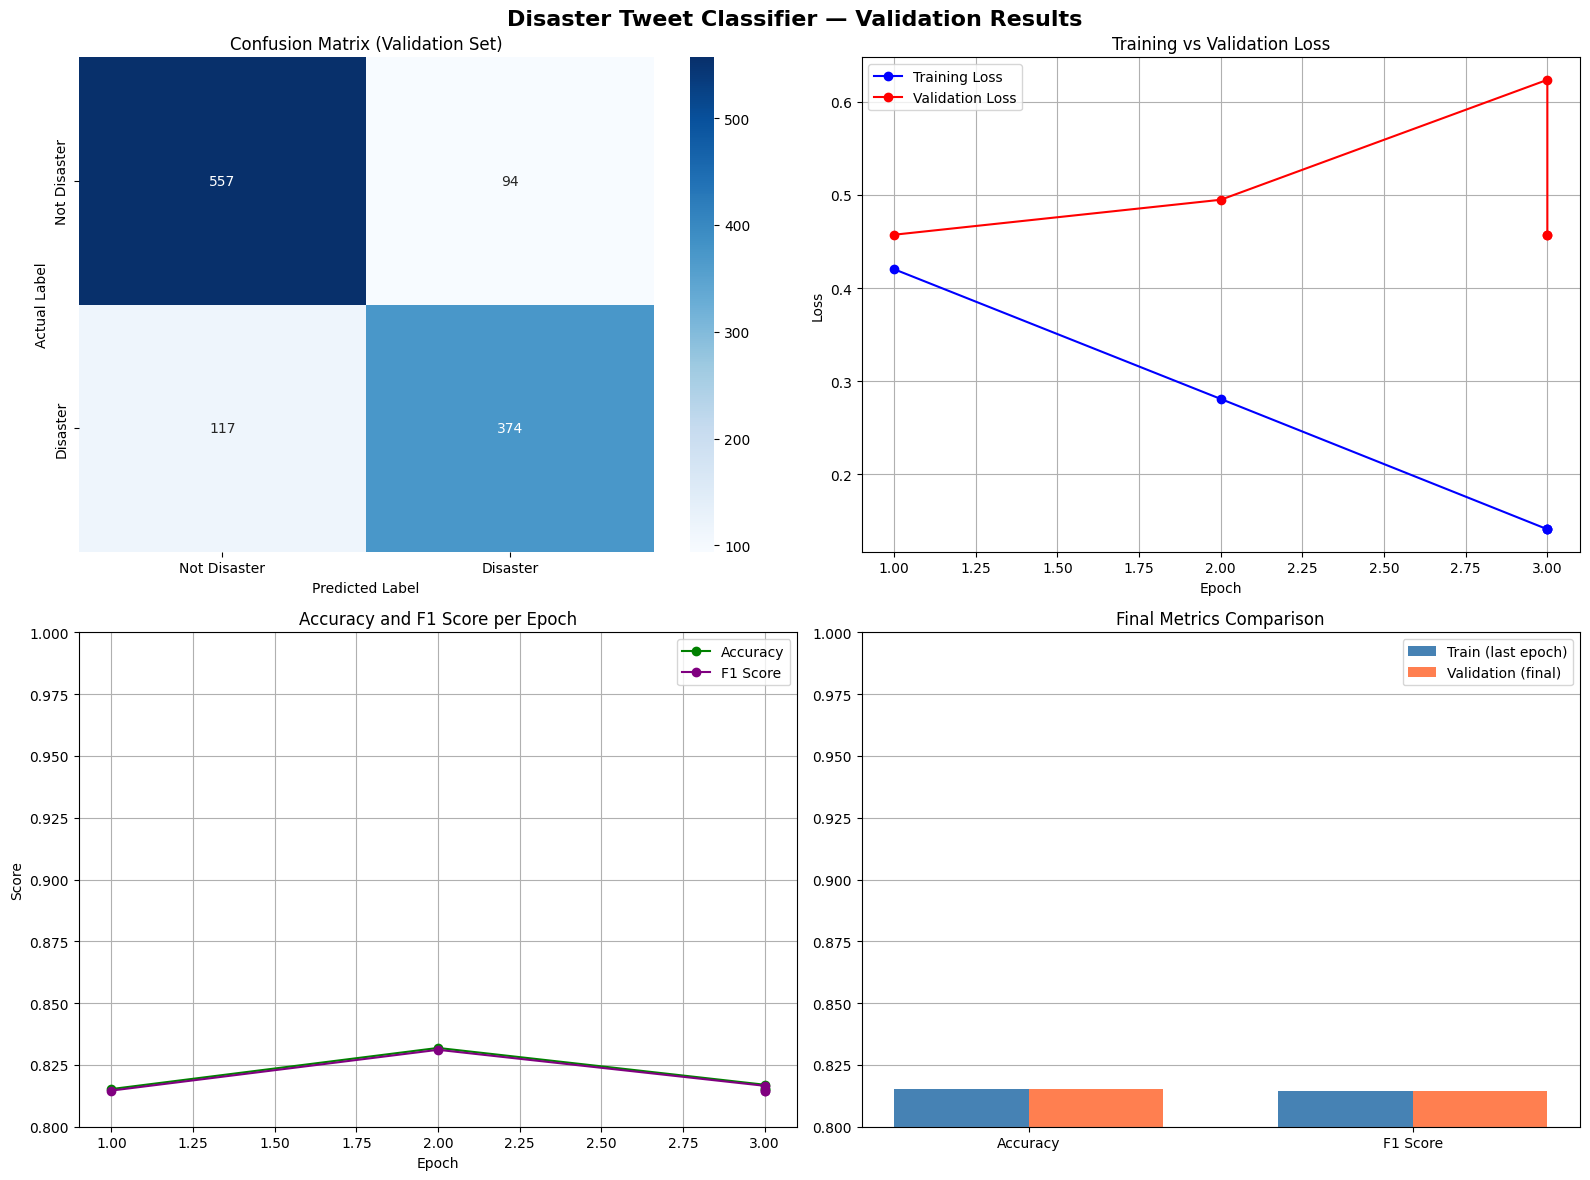


Detailed Classification Report (Validation Set):
              precision    recall  f1-score   support

Not Disaster       0.83      0.86      0.84       651
    Disaster       0.80      0.76      0.78       491

    accuracy                           0.82      1142
   macro avg       0.81      0.81      0.81      1142
weighted avg       0.81      0.82      0.81      1142

FINAL VALIDATION SUMMARY
  Total tweets evaluated:  1142
  Correctly classified:    931
  Incorrectly classified:  211
  Val Accuracy:            0.8152
  Val F1 Score:            0.8146

Next step: Run Cell 9 to generate Kaggle submission predictions!


In [ ]:
# Cell 8 - Final Comparison and Metrics
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Now that we have predictions and true labels from the validation set,
# we create a full picture of model performance.
# (We use validation set here because Kaggle test.csv has no ground-truth labels.)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Disaster Tweet Classifier — Validation Results', fontsize=16, fontweight='bold')

# ---- GRAPH 1: Confusion Matrix ----
# Shows exactly what the model got right and wrong by class:
# - How many real disasters did it correctly flag?
# - How many non-disasters did it correctly flag?
# - How often did it confuse one for the other?
cm = confusion_matrix(true_labels, predicted_labels)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Not Disaster', 'Disaster'],
    yticklabels=['Not Disaster', 'Disaster'],
    ax=axes[0, 0]
)
axes[0, 0].set_title('Confusion Matrix (Validation Set)')
axes[0, 0].set_ylabel('Actual Label')
axes[0, 0].set_xlabel('Predicted Label')

# ---- GRAPH 2: Loss Curve ----
# Replots training vs validation loss so it appears in the final report
axes[0, 1].plot(history['epoch'], history['training_loss'], 'b-o', label='Training Loss')
axes[0, 1].plot(history['epoch'], history['validation_loss'], 'r-o', label='Validation Loss')
axes[0, 1].set_title('Training vs Validation Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True)

# ---- GRAPH 3: Accuracy and F1 per Epoch ----
# Shows both metrics together across all epochs on the validation set
axes[1, 0].plot(history['epoch'], history['accuracy'], 'g-o', label='Accuracy')
axes[1, 0].plot(history['epoch'], history['f1'], 'purple', marker='o', label='F1 Score')
axes[1, 0].set_title('Accuracy and F1 Score per Epoch')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Score')
axes[1, 0].set_ylim([0.8, 1.0])
axes[1, 0].legend()
axes[1, 0].grid(True)

# ---- GRAPH 4: Final Metrics Bar Chart ----
# Compares training metrics vs final validation metrics side by side
metrics = ['Accuracy', 'F1 Score']
train_scores = [history['accuracy'][-1], history['f1'][-1]]           # from live training history
val_scores   = [val_analysis_results['eval_accuracy'], val_analysis_results['eval_f1']]  # final stable val metrics

x = np.arange(len(metrics))
width = 0.35

axes[1, 1].bar(x - width/2, train_scores, width, label='Train (last epoch)', color='steelblue')
axes[1, 1].bar(x + width/2, val_scores,   width, label='Validation (final)', color='coral')
axes[1, 1].set_title('Final Metrics Comparison')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(metrics)
axes[1, 1].set_ylim([0.8, 1.0])
axes[1, 1].legend()
axes[1, 1].grid(True, axis='y')

plt.tight_layout()
plt.savefig('final_results.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- CLASSIFICATION REPORT ----
# Detailed breakdown of precision, recall, and F1 for each class
print("\nDetailed Classification Report (Validation Set):")
print(classification_report(
    true_labels,
    predicted_labels,
    target_names=['Not Disaster', 'Disaster']
))

# ---- SUMMARY ----
print("FINAL VALIDATION SUMMARY")
print(f"  Total tweets evaluated:  {len(true_labels)}")
print(f"  Correctly classified:    {sum(predicted_labels == true_labels)}")
print(f"  Incorrectly classified:  {sum(predicted_labels != true_labels)}")
print(f"  Val Accuracy:            {val_analysis_results['eval_accuracy']:.4f}")
print(f"  Val F1 Score:            {val_analysis_results['eval_f1']:.4f}")
print("\nNext step: Run Cell 9 to generate Kaggle submission predictions!")

In [ ]:
# Cell 9 - Save Project to Drive
# This cell saves the entire Colab notebook to your Google Drive for backup and persistence.
import os

# Define the name of the notebook file
notebook_name = "Disaster_Tweet_Classification.ipynb"

# Define the destination path in Google Drive
drive_path = "/content/drive/MyDrive/Colab Notebooks/"

# Ensure the destination directory exists in Google Drive
# This command will create the directory if it doesn't already exist
!mkdir -p "{drive_path}"

# Copy the current notebook to Google Drive
# The '!' prefix allows running shell commands directly in Colab
!cp "{notebook_name}" "{drive_path}{notebook_name}"

print(f"Notebook '{notebook_name}' saved to '{drive_path}'")

cp: cannot stat 'Disaster_Tweet_Classification.ipynb': No such file or directory
Notebook 'Disaster_Tweet_Classification.ipynb' saved to '/content/drive/MyDrive/Colab Notebooks/'
